# Notebook for constructing age models for the Mamainse Point Volcanics

In [11]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## Maminase Point Volcanics

- The bottom of the section (lower R1 pole) is > ca. 1107 Ma, let's set it to be 1110 Ma which is thought to be the beginnin of the Midcontinent Rift
- The Flour Bay Tuff is dated to be 1100.36 $\pm$ 0.25 Ma which can be used as one constraint at strat height 2000
- The top of the section is of normal polarity with no radiometric constraints, let's set it to be 1090 $\pm$ 4 Ma

In [12]:
Mamainse_Name = ("Base of Mamainse", "Agate Point rhyolite flow", "Top of Osler") # Et cetera
Mamainse_Age           = [ 1110, 1100.36, 1090] # Measured ages
Mamainse_Age_sigma     = [ 2/2,     0.25/2, 4/2] # Measured 1-σ uncertainties
Mamainse_Height        = [ 0.0,     2000,  4100] # Depths below surface should be negative
Mamainse_Age_Sidedness = [0, 0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Mamainse_Path = "../../data/age_models_output/Mamainse_Point_Volcanic_Group" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Mamainse_section = make_ChronAgeData(Mamainse_Name, Mamainse_Age, Mamainse_Age_sigma, Mamainse_Height, Mamainse_Age_Sidedness, Mamainse_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{3}(("Base of Mamainse", "Agate Point rhyolite flow", "Top of Osler"), [0.0, 2000.0, 4100.0], [0.01, 0.01, 0.01], [1110.0, 1100.36, 1090.0], [1.0, 0.125, 2.0], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [#undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer), [NaN NaN NaN; NaN NaN NaN; … ; NaN NaN NaN; NaN NaN NaN], "../../data/age_models_output/Mamainse_Point_Volcanic_Group", 2, "Ma", "m", :cdf)

In [13]:
Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, Mamainse_age_model_lldist = run_age_model(Mamainse_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 575000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 575000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 575000, 1000, 575, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  4010.0, 4020.0, 4030.0, 4040.0, 4050.0, 4060.0, 4070.0, 4080.0, 4090.0, 4100.0], [1110.0827079976468, 1110.0368382482025, 1109.9746644394256, 1109.9259214551294, 1109.869804373637, 1109.8173000424592, 1109.770112031004, 1109.718755102104, 1109.68822230959, 1109.6493521257705  …  1090.403992849927, 1090.35621800488, 1090.3263592138253, 1090.277354267895, 1090.2384554966259, 1090.1830985634374, 1090.099680499141, 1090.0375955111292, 1089.996374658414, 1089.9399233366792], [0.9167251690543293, 0.9502668250960934, 1.0021569093126508, 1.0317002113795781, 1.0717476740938356, 1.1089992975413931, 1.131473725435885, 1.1622282923605756, 1.191975751396523, 1.2095582043457944  …  1.666046710745563, 1.6405351397556853, 1.6233288712788139, 1.6176296229235796, 1.6056646485990187, 1.5804162999262754, 1.5615389658392596, 1.5432850204005875, 1.538092315181034, 1.5153981

### posterior summary age model

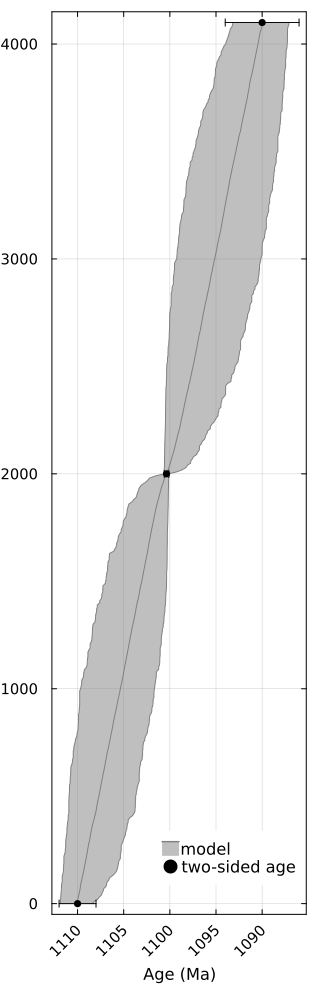

In [14]:
Mamainse_age_model = plot_age_model(Mamainse_section, Mamainse_age_model_mdl, save_figure=false)
plot!(ylim=(-50, 4150))
# savefig(Mamainse_age_model, Mamainse_section.Path*"_AgeDepthModel.pdf")
display(Mamainse_age_model)

### example posterior accumulation models

agemin: 1089.9399233366792, agemax: 1110.0827079976468, halfw: 0.25, Δt: 0.1
Number of windows: 197
  0.109627 seconds (9.00 k allocations: 10.437 MiB, 0.36% gc time)


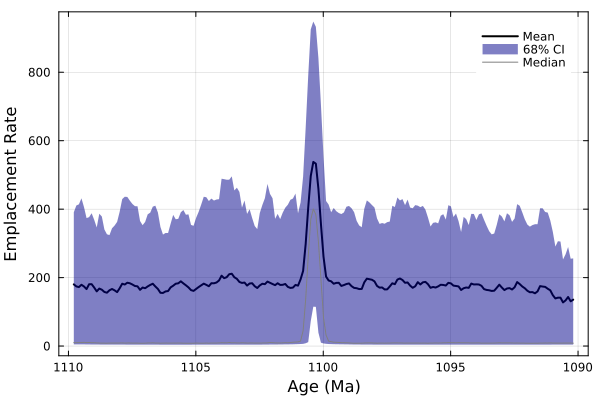

In [18]:
plot_accumulation_model(Mamainse_section, Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, binwidth=0.5, stepfrac=0.2, save_figure=false)

### example posterior age models

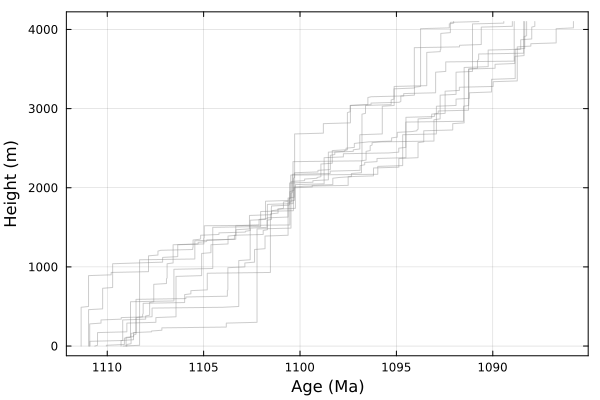

In [6]:
plot_posterior_paths(Mamainse_section, Mamainse_age_model_agedist, Mamainse_age_model_mdl)

## save the age models to a file

In [7]:
# use the mdl.height as index, agedist as the data
Mamainse_age_models_df = DataFrame(hcat(Mamainse_age_model_mdl.Height, Mamainse_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Mamainse_age_models_df, Dict(:x1 => "height"))
Mamainse_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1110.13,1110.98,1109.88,1109.88,1109.55,1110.6,1109.57,1112.08,1110.73,1109.24,1109.96,1110.84,1110.04,1111.48,1111.63,1109.52,1109.82,1109.81,1108.4,1109.93,1110.35,1110.72,1109.83,1109.55,1109.54,1111.38,1110.29,1110.74,1108.56,1108.96,1110.76,1108.2,1109.13,1110.42,1109.56,1109.6,1109.43,1108.04,1110.19,1110.71,1110.89,1109.46,1109.56,1108.92,1109.27,1109.13,1109.81,1109.81,1111.37,1109.0,1107.81,1109.35,1110.0,1111.45,1110.4,1111.52,1110.59,1108.47,1109.06,1110.28,1110.94,1110.49,1110.23,1108.05,1110.78,1109.67,1110.39,1109.9,1108.69,1110.0,1109.28,1110.13,1109.07,1108.53,1110.09,1110.18,1109.53,1110.81,1109.49,1109.52,1110.08,1111.13,1109.86,1109.64,1111.14,1111.1,1109.63,1111.29,1109.53,1111.99,1108.84,1110.91,1109.97,1109.44,1109.48,1109.23,1108.26,1109.44,1111.53,⋯
2,10.0,1110.13,1110.98,1109.88,1109.88,1109.55,1110.2,1109.57,1111.53,1110.73,1109.24,1109.96,1110.84,1110.04,1111.48,1111.63,1109.52,1109.82,1109.81,1108.4,1109.93,1110.35,1110.72,1109.83,1109.55,1109.54,1111.38,1110.29,1109.38,1108.56,1108.96,1110.76,1107.67,1109.13,1110.42,1109.56,1109.6,1109.43,1108.04,1110.19,1110.71,1110.89,1109.46,1109.56,1108.92,1109.27,1109.13,1109.81,1109.81,1111.37,1109.0,1107.81,1109.35,1110.0,1111.45,1110.4,1111.52,1110.59,1108.47,1109.06,1110.28,1110.94,1110.49,1110.23,1108.05,1110.78,1109.67,1110.39,1109.9,1108.69,1110.0,1109.28,1110.13,1109.07,1108.53,1110.09,1110.18,1109.36,1110.81,1109.49,1109.52,1109.93,1111.13,1109.86,1109.36,1111.14,1111.1,1109.63,1111.29,1109.53,1111.99,1108.84,1110.91,1109.97,1109.44,1109.48,1109.23,1108.26,1107.57,1111.53,⋯
3,20.0,1110.13,1110.98,1109.88,1109.88,1109.55,1110.2,1109.57,1111.53,1110.73,1109.24,1109.96,1110.84,1110.04,1111.48,1111.63,1109.52,1109.82,1109.81,1108.4,1109.93,1110.35,1110.72,1109.83,1109.55,1109.54,1111.38,1110.29,1108.8,1108.39,1108.96,1110.76,1107.67,1109.13,1110.42,1109.56,1109.6,1109.43,1107.67,1110.19,1110.71,1110.89,1109.46,1109.56,1108.92,1109.27,1109.13,1109.81,1107.88,1111.37,1109.0,1107.71,1109.35,1110.0,1111.45,1110.4,1111.52,1110.59,1108.47,1109.06,1110.28,1110.94,1110.49,1110.23,1108.05,1109.81,1109.67,1110.39,1109.9,1108.69,1110.0,1109.28,1110.13,1109.07,1108.53,1110.09,1110.18,1109.36,1110.81,1109.49,1109.52,1109.93,1111.13,1109.86,1109.36,1111.14,1111.1,1109.63,1111.29,1109.53,1111.99,1108.84,1110.91,1109.97,1109.44,1109.48,1109.23,1108.26,1106.88,1111.53,⋯
4,30.0,1110.13,1110.98,1109.88,1109.88,1109.55,1110.2,1109.57,1111.53,1110.73,1109.24,1109.96,1110.84,1110.04,1111.35,1111.63,1109.52,1108.26,1109.8,1108.4,1109.93,1110.35,1110.72,1109.83,1109.55,1109.54,1111.38,1110.29,1108.8,1108.39,1108.96,1110.76,1107.67,1109.13,1110.42,1109.56,1109.6,1109.43,1107.67,1110.19,1110.71,1110.89,1109.46,1109.56,1108.92,1109.27,1109.13,1109.81,1107.88,1111.37,1109.0,1107.71,1109.35,1110.

In [8]:
# write the DataFrame to a csv file
CSV.write(Mamainse_section.Path*"_posterior_ages.csv", Mamainse_age_models_df)

"../../data/age_models_output/Mamainse_Point_Volcanic_Group_posterior_ages.csv"